<a href="https://colab.research.google.com/github/madhumi2611/Airline-Ticket-Price-Prediction-using-16-ML-models/blob/main/CNNvsDNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Training CNN Model...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6004/6004 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - loss: 303690336.0000 - mae: 12583.2021 - val_loss: 47336748.0000 - val_mae: 4340.6191
Epoch 2/50
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 65819000.0000 - mae: 5151.0034 - val_loss: 32832434.0000 - val_mae: 3464.4053
Epoch 3/50
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - loss: 52408664.0000 - mae: 4469.4097 - val_loss: 37576648.0000 - val_mae: 3657.3235
Epoch 4/50
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 47004272.0000 - mae: 4213.9556 - val_loss: 28765344.0000 - val_mae: 3259.0398
Epoch 5/50
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 43278956.0000 - mae: 4036.0176 - val_loss: 35782204.0000 - val_mae: 3718.7961
Epoch 6/50
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 41440332.0000 - mae: 3937.4160 - val_loss: 37142264.0000 - val_mae: 3753.5610
Epoch 7/50
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 39188040.0000 - mae: 3830.5715 - val_loss: 35440612.0000 - val_mae: 3784.3250
Epoch 8/50
6004/6004 ━

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6004/6004 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - loss: 435002880.0000 - mae: 12376.6777 - val_loss: 21308520.0000 - val_mae: 3068.3650
Epoch 2/100
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 32988312.0000 - mae: 3926.1755 - val_loss: 19361458.0000 - val_mae: 2702.1570
Epoch 3/100
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 26974270.0000 - mae: 3400.0681 - val_loss: 19670666.0000 - val_mae: 2814.6294
Epoch 4/100
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - loss: 25313600.0000 - mae: 3255.1892 - val_loss: 18649312.0000 - val_mae: 2652.6094
Epoch 5/100
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 24129300.0000 - mae: 3122.1436 - val_loss: 17540114.0000 - val_mae: 2499.8926
Epoch 6/100
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 23307478.0000 - mae: 3048.5806 - val_loss: 17799210.0000 - val_mae: 2540.1187
Epoch 7/100
6004/6004 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 22577886.0000 - mae: 2975.3521 - val_loss: 16931070.0000 - val_mae: 2454.4924
Epoch 8/100
6004

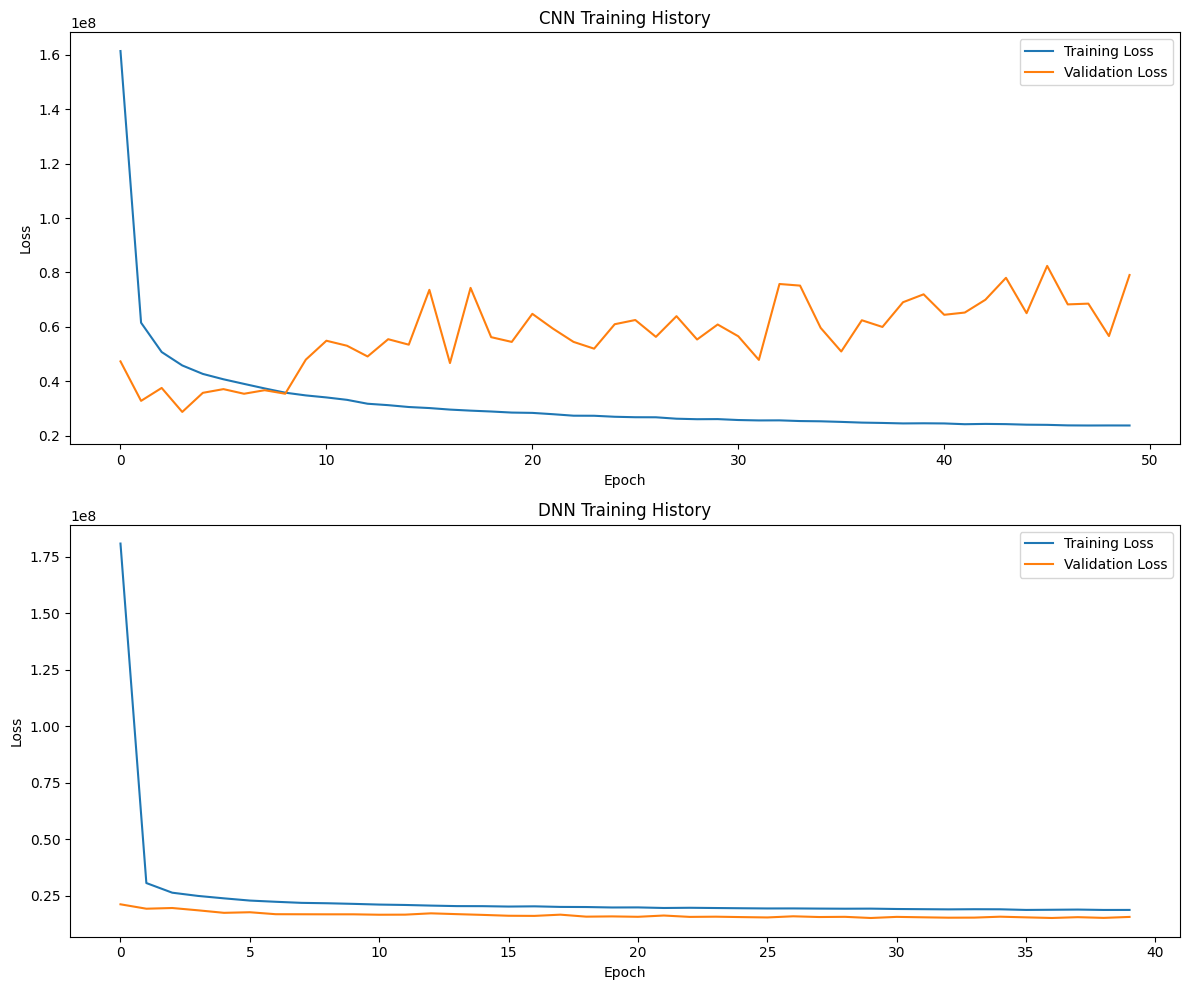


Final Model Comparison (sorted by RMSE):
  Model         RMSE          MAE  R2 Score
1   DNN  3955.422733  2321.518799  0.969649
0   CNN  8920.635403  5623.662598  0.845625


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Clean_Dataset.csv')

# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 0', 'flight'])

# Convert categorical variables
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# Define features and target
X = df.drop(columns=['price'])
y = df['price']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for numerical and categorical features
numeric_features = ['duration', 'days_left']
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_features = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])
results_df=[]
# CNN Implementation
print("\nTraining CNN Model...")
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the number of features after preprocessing
n_features = X_train_processed.shape[1]

# Reshape data for CNN
X_train_cnn = X_train_processed.toarray().reshape(X_train_processed.shape[0], X_train_processed.shape[1], 1)
X_test_cnn = X_test_processed.toarray().reshape(X_test_processed.shape[0], X_test_processed.shape[1], 1)

# Build CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_features, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mean_squared_error',
                  metrics=['mae'])

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate CNN
y_pred_cnn = cnn_model.predict(X_test_cnn).flatten()
cnn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
cnn_mae = mean_absolute_error(y_test, y_pred_cnn)
cnn_r2 = r2_score(y_test, y_pred_cnn)

print("\nCNN Performance:")
print(f"RMSE: {cnn_rmse:.2f}")
print(f"MAE: {cnn_mae:.2f}")
print(f"R2 Score: {cnn_r2:.2f}")

# DNN Implementation
print("\nTraining DNN Model...")
# Preprocess data for DNN (same as CNN preprocessing)
X_train_dnn = X_train_processed.toarray()
X_test_dnn = X_test_processed.toarray()

# Build DNN model
dnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile the model
dnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mean_squared_error',
                  metrics=['mae'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the DNN
history_dnn = dnn_model.fit(
    X_train_dnn, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate DNN
y_pred_dnn = dnn_model.predict(X_test_dnn).flatten()
dnn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
dnn_mae = mean_absolute_error(y_test, y_pred_dnn)
dnn_r2 = r2_score(y_test, y_pred_dnn)

print("\nDNN Performance:")
print(f"RMSE: {dnn_rmse:.2f}")
print(f"MAE: {dnn_mae:.2f}")
print(f"R2 Score: {dnn_r2:.2f}")

# Plot training history for both neural networks
plt.figure(figsize=(12, 10))

# CNN training history
plt.subplot(2, 1, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# DNN training history
plt.subplot(2, 1, 2)
plt.plot(history_dnn.history['loss'], label='Training Loss')
plt.plot(history_dnn.history['val_loss'], label='Validation Loss')
plt.title('DNN Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Add CNN and DNN results to comparison
results_df.append({
    'Model': 'CNN',
    'RMSE': cnn_rmse,
    'MAE': cnn_mae,
    'R2 Score': cnn_r2
})

results_df.append({
    'Model': 'DNN',
    'RMSE': dnn_rmse,
    'MAE': dnn_mae,
    'R2 Score': dnn_r2
})

results

# Final comparison
print("\nFinal Model Comparison (sorted by RMSE):")
print(results_df.sort_values(by='RMSE'))